# GPU Benchmark Results Analysis
Analyzing execution times across N multiple runs with boxplots to visualize variance.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("gpu_stats_results.csv")

# Identify run columns dynamically (run_1, run_2, etc.)
run_cols = [c for c in df.columns if c.startswith("run_")]

# Melt the dataframe to have run_id and execution_time for boxplots
df_melted = df.melt(id_vars=["model", "schema", "num_inputs"], 
                    value_vars=run_cols, 
                    var_name="run_id", 
                    value_name="execution_time")

# Display the summarized stats table
stats_cols = ["model", "num_inputs", "median", "mean_arith", "mean_geom", "variance", "ci_lower", "ci_upper"]
df[stats_cols]

,model,num_inputs,median,mean_arith,mean_geom,variance,ci_lower,ci_upper
0,giant_cpu.pt,100000,1.9559,1.9675,1.9672,0.001398,1.9443,1.9906
1,giant_cuda.pt,100000,1.9450,1.9472,1.9472,0.000081,1.9416,1.9527
2,transformer_cpu.pt,1000000,0.3996,0.4496,0.4335,0.024883,0.3519,0.5474
3,transformer_cuda.pt,1000000,0.4011,0.4168,0.4146,0.002391,0.3865,0.4471
4,transformer_inference_scripted_fw2.pt,10000,2.2488,2.5528,2.4506,0.913025,1.9605,3.1450
5,perfect_cpu.pt,100000000,1.2147,1.2578,1.2510,0.020501,1.1691,1.3466
6,perfect_cuda.pt,100000000,1.6082,1.6247,1.5949,0.115869,1.4137,1.8356
7,watercnn_cpu.pt,10000000,0.1650,0.1908,0.1823,0.004887,0.1475,0.2341
8,watercnn_cuda.pt,10000000,0.1572,0.1968,0.1892,0.004124,0.1570,0.2366


/tmp/ro092286/login23-g-1_202374/ipykernel_246316/827043058.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted, x="model", y="execution_time", palette="Set2")


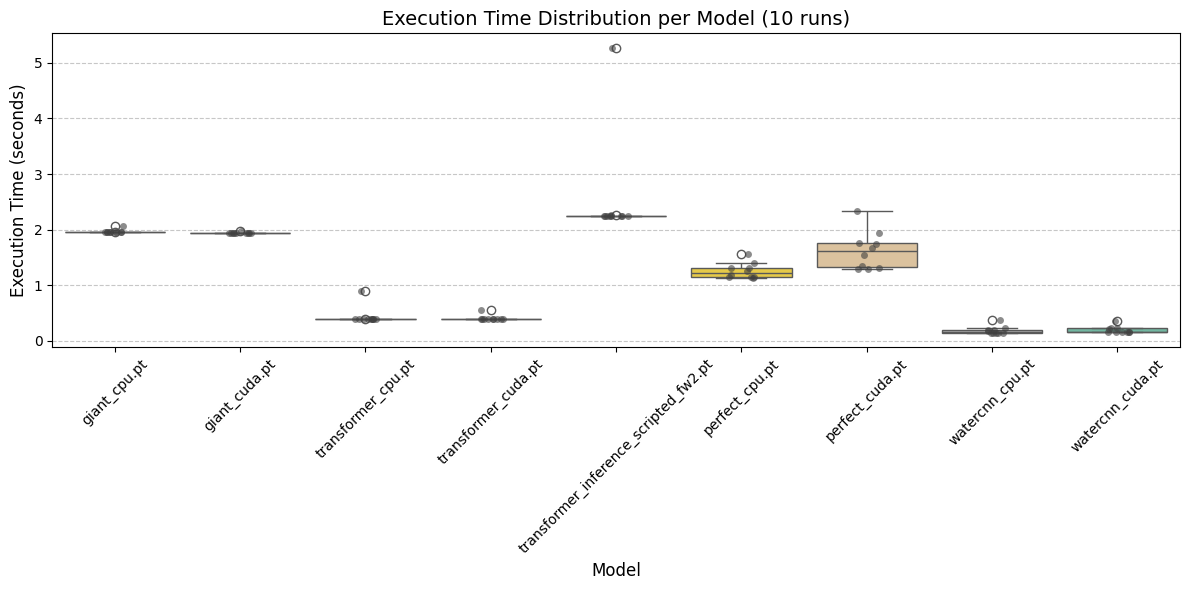

In [5]:
# Plot execution time distribution using Boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melted, x="model", y="execution_time", palette="Set2")
sns.stripplot(data=df_melted, x="model", y="execution_time", color=".25", alpha=0.6, jitter=True)

plt.title("Execution Time Distribution per Model (10 runs)", fontsize=14)
plt.ylabel("Execution Time (seconds)", fontsize=12)
plt.xlabel("Model", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, axis="y", ls="--", alpha=0.7)
plt.tight_layout()
plt.show()